In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset_titanic = r"C:\Users\f.gionnane\Documents\TechnoFuturTIC\EDA, Machine Learning and Data Mining\Machine Learning and Data Mining\Datasets-20250410\titanic3.xls"

In [3]:
df_titanic = pd.read_excel(dataset_titanic,engine='xlrd')
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


EDA sur le dataset Titanic

Diverses analyses univariées

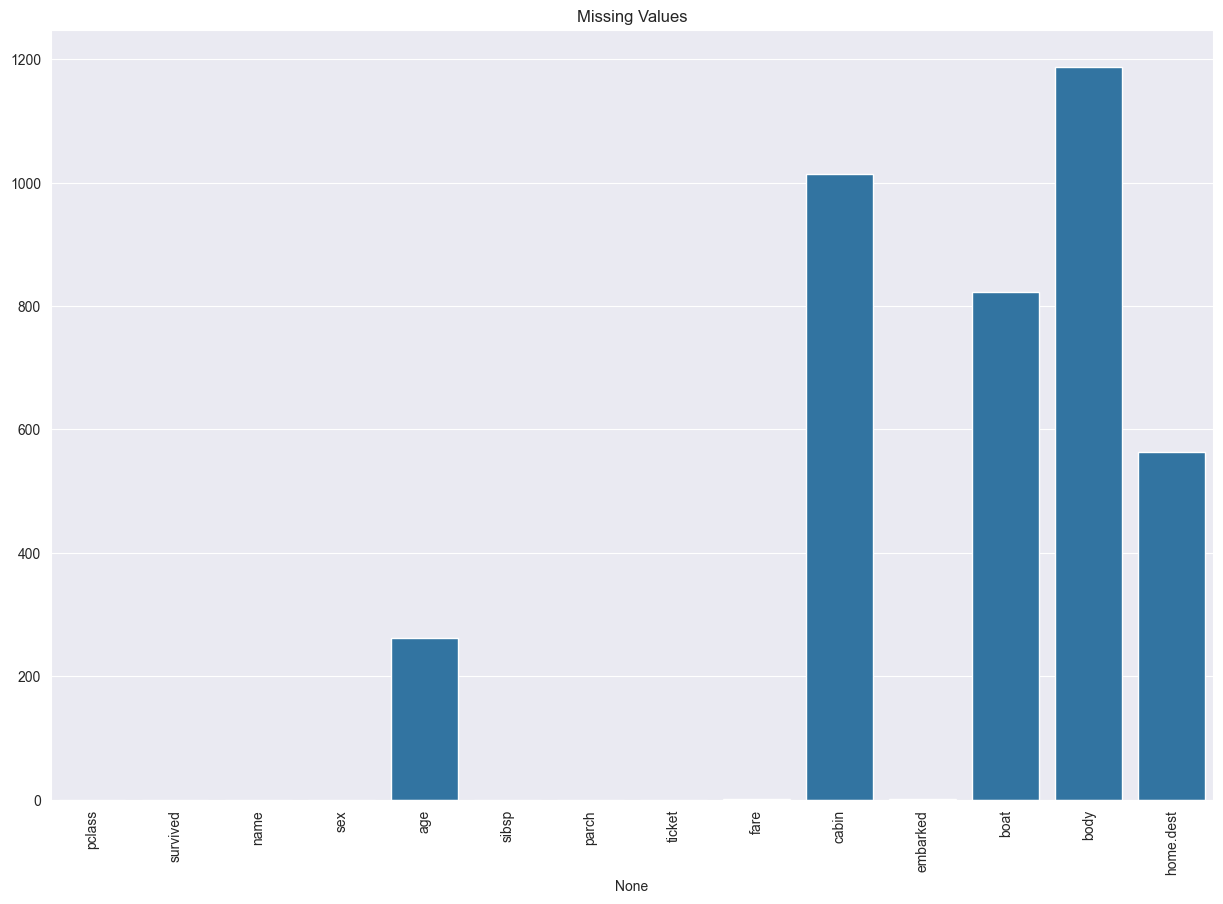

In [4]:
# analyse du nombre de valeurs nulles

FIGSIZE = (15, 10)
sns.set_style('darkgrid')

plt.figure(figsize=FIGSIZE)
plt.title('Missing Values')

missing_values = df_titanic.isnull().sum()
sns.barplot(x=missing_values.index, y = missing_values.values)

plt.xticks(rotation=90)

plt.show()

<Axes: title={'center': 'Age Distribution'}, xlabel='age', ylabel='Count'>

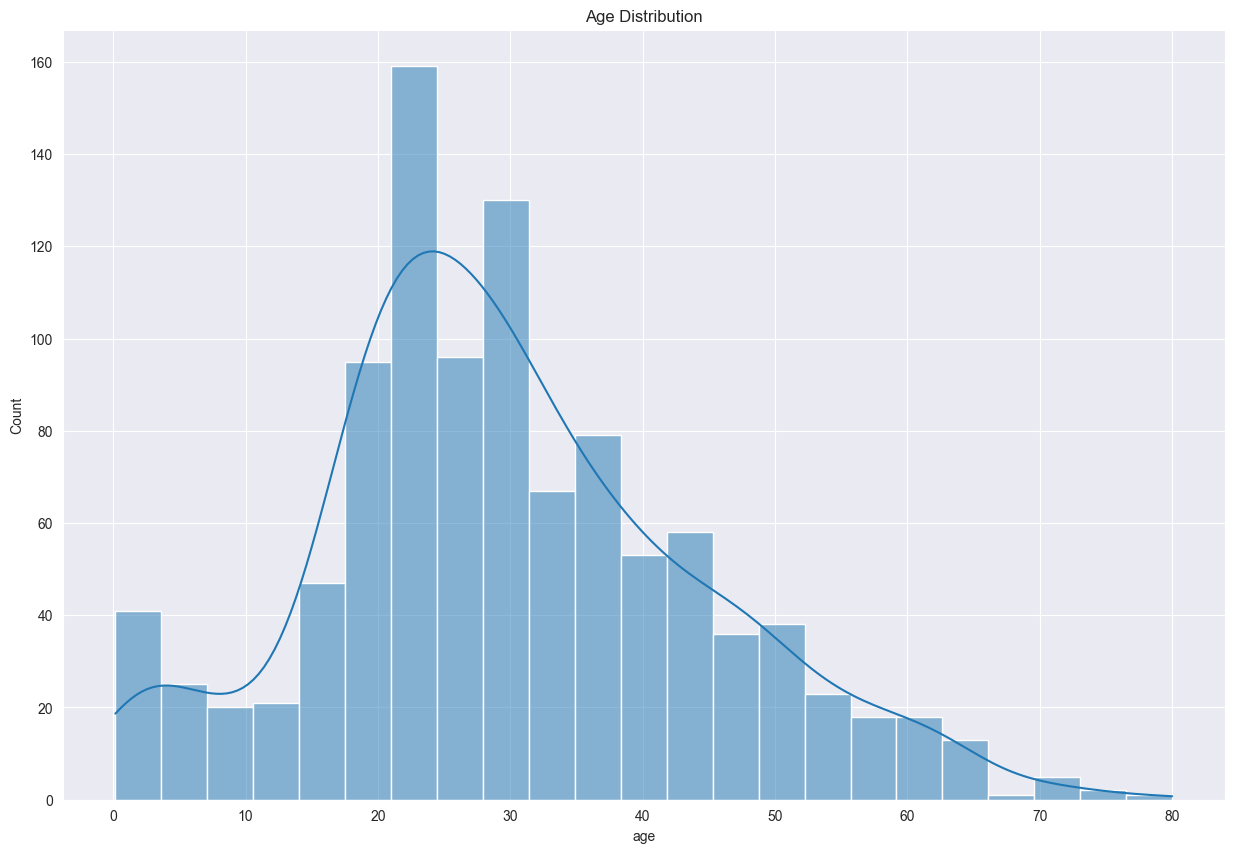

In [5]:
# Analyse de la distribution des âges

plt.figure(figsize=FIGSIZE)
plt.title('Age Distribution')

sns.histplot(data=df_titanic, x='age', kde=True)

In [6]:
continuous_feature = df_titanic.select_dtypes(include=[float, int])
continuous_feature

,pclass,survived,age,sibsp,parch,fare,body
0,1,1,29.0000,0,0,211.3375,NaN
1,1,1,0.9167,1,2,151.5500,NaN
2,1,0,2.0000,1,2,151.5500,NaN
3,1,0,30.0000,1,2,151.5500,135.0
4,1,0,25.0000,1,2,151.5500,NaN
...,...,...,...,...,...,...,...
1304,3,0,14.5000,1,0,14.4542,328.0
1305,3,0,NaN,1,0,14.4542,NaN
1306,3,0,26.5000,0,0,7.2250,304.0
1307,3,0,27.0000,0,0,7.2250,NaN


In [11]:
#virer boat et name

try:
    df_titanic = df_titanic.drop(['boat', 'name'], axis=1)
except:
    pass
df_titanic.info()

cat_feature = df_titanic.select_dtypes(exclude=[float, int])
cat_feature

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   sex        1309 non-null   object 
 3   age        1046 non-null   float64
 4   sibsp      1309 non-null   int64  
 5   parch      1309 non-null   int64  
 6   ticket     1309 non-null   object 
 7   fare       1308 non-null   float64
 8   cabin      295 non-null    object 
 9   embarked   1307 non-null   object 
 10  body       121 non-null    float64
 11  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


,sex,ticket,cabin,embarked,home.dest
0,female,24160,B5,S,"St Louis, MO"
1,male,113781,C22 C26,S,"Montreal, PQ / Chesterville, ON"
2,female,113781,C22 C26,S,"Montreal, PQ / Chesterville, ON"
3,male,113781,C22 C26,S,"Montreal, PQ / Chesterville, ON"
4,female,113781,C22 C26,S,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...
1304,female,2665,NaN,C,NaN
1305,female,2665,NaN,C,NaN
1306,male,2656,NaN,C,NaN
1307,male,2670,NaN,C,NaN


Analyses bivariées

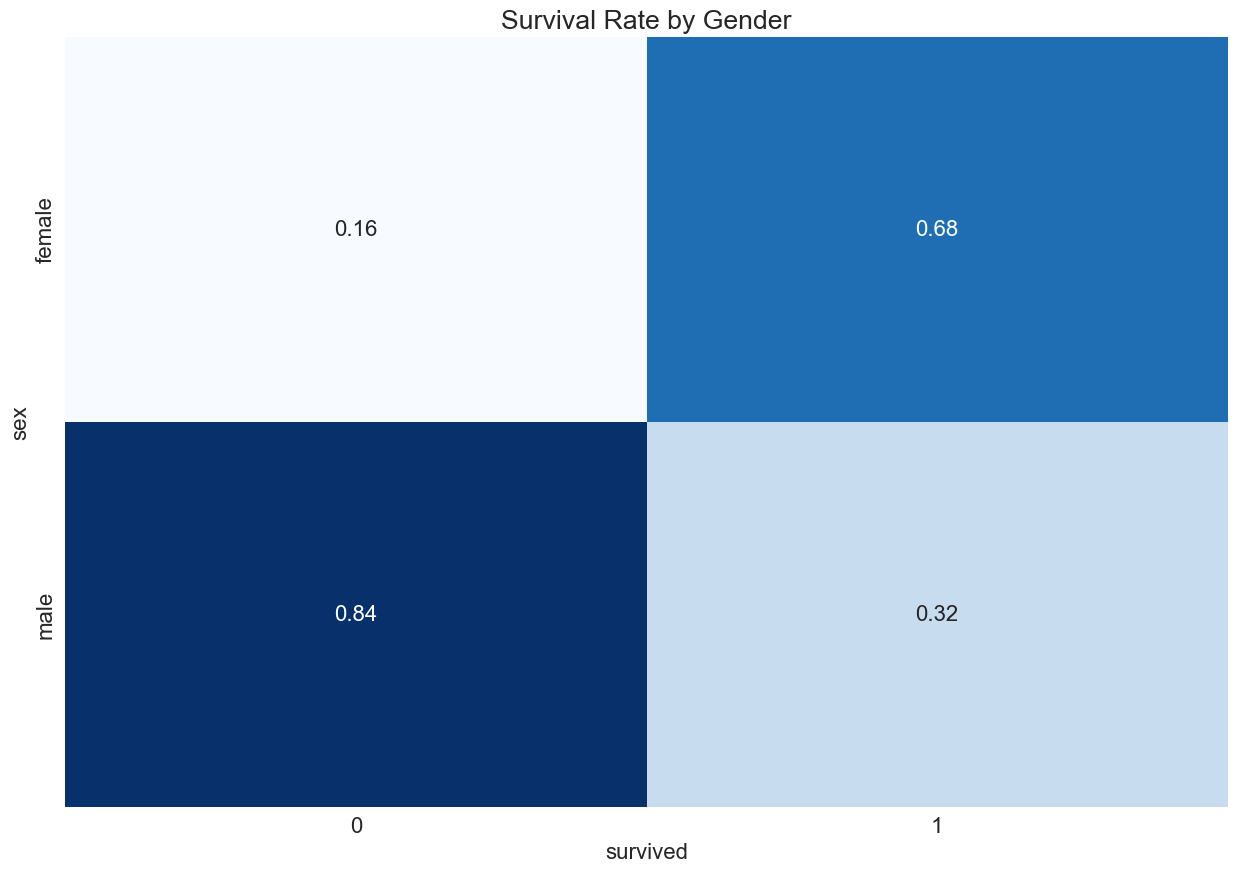

In [10]:
# crossplot des variables catégorielles
cross_gender_survived = pd.crosstab(df_titanic['sex'], df_titanic['survived'], normalize='columns')
# choisir une police visible

plt.rc('font', size=16)
plt.figure(figsize=(15, 10))
plt.title('Survival Rate by Gender')
sns.heatmap(cross_gender_survived, cbar=False, annot=True, cmap='Blues')

plt.show()

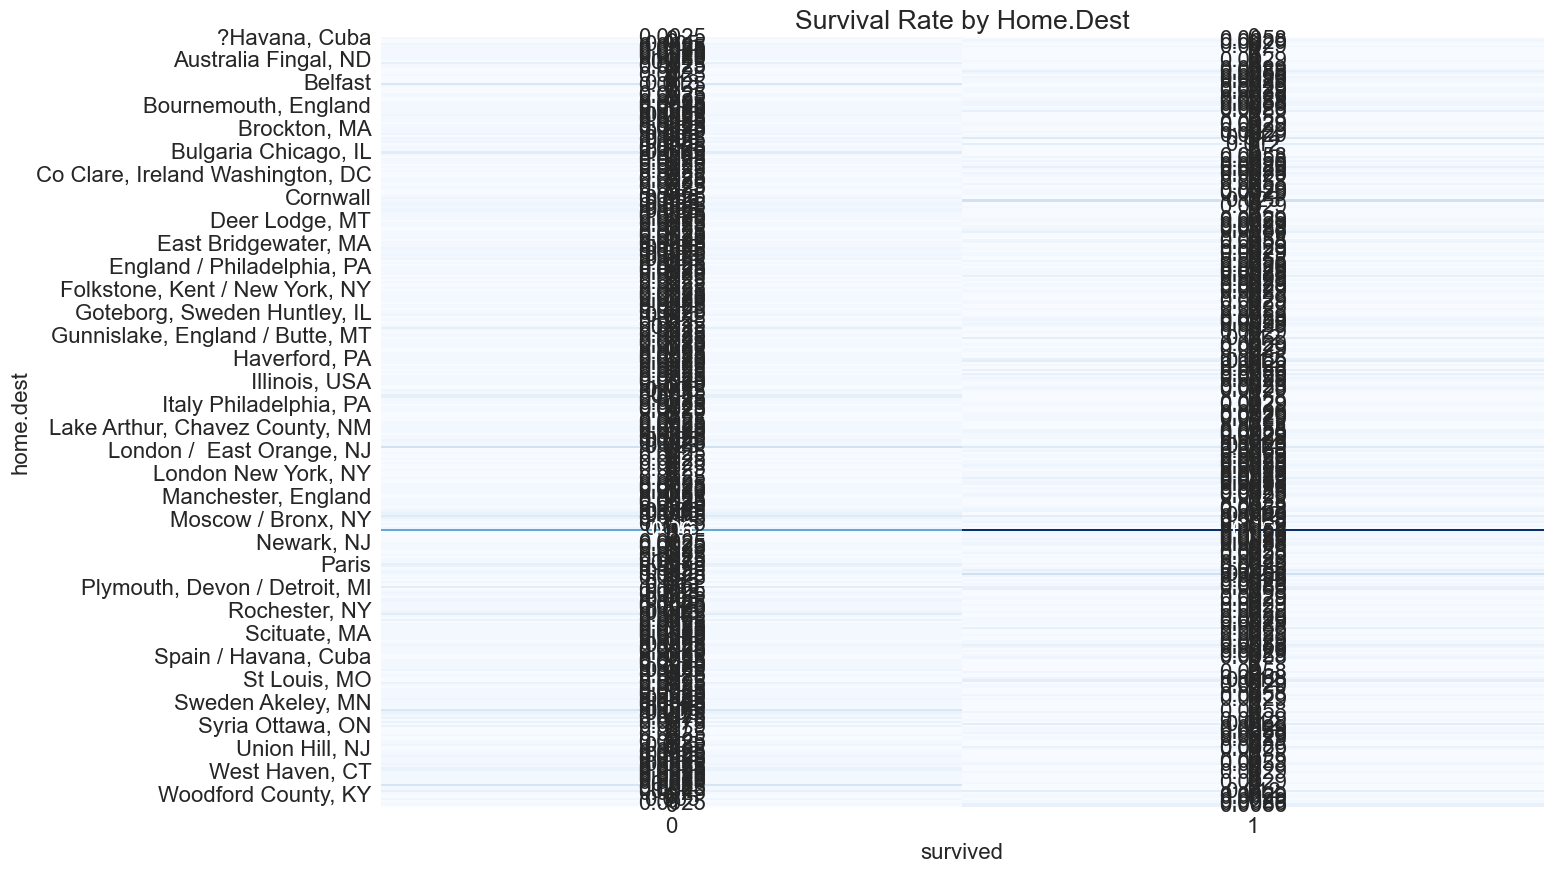

In [12]:
#analyse bivariée sur les catégories : survie et home.dest

cross_home_dest_survived = pd.crosstab(df_titanic['home.dest'], df_titanic['survived'], normalize='columns')
plt.rc('font', size=16)
plt.figure(figsize=(15, 10))
plt.title('Survival Rate by Home.Dest')
sns.heatmap(cross_home_dest_survived, cbar=False, annot=True, cmap='Blues')

plt.show()